# Lista 12 — GQA: Grouped Query Attention

Eksperymenty badające efekt GQA w klasyfikacji tekstu z enkoderem (IMDB sentiment).

**Źródło:** Ainslie et al., *GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints*, EMNLP 2023. https://arxiv.org/abs/2305.13245

## Planowane eksperymenty
1. Różne wartości G (G=1,2,4,8) — główny tradeoff
2. Strategia grupowania (naiwna, losowa, odwrotna) przy G=2
3. Długość sekwencji (64, 128, 256, 512) × G
4. Layer-wise GQA (GQA tylko w wybranych warstwach)

## 0. Instalacja i importy

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import time
import math
import random
from collections import defaultdict
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce GTX 1080
VRAM: 8.6 GB


## 1. MLflow setup

In [12]:
import socket

MLFLOW_URI = 'http://localhost:5002'

def mlflow_available(host='localhost', port=5002, timeout=2):
    try:
        socket.setdefaulttimeout(timeout)
        socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect((host, port))
        return True
    except Exception:
        return False

if mlflow_available():
    mlflow.set_tracking_uri(MLFLOW_URI)
    print(f'MLflow: {MLFLOW_URI}')
else:
    mlflow.set_tracking_uri('./mlruns')
    print('MLflow: lokalny folder ./mlruns (serwer niedostępny)')

mlflow.set_experiment('GQA_Classification')

MLflow: lokalny folder ./mlruns (serwer niedostępny)


<Experiment: artifact_location='/home/mikol/ai_studies/Deep-Neural-Networks-PWR/lab11/mlruns/316269890289944885', creation_time=1780698704515, experiment_id='316269890289944885', last_update_time=1780698704515, lifecycle_stage='active', name='GQA_Classification', tags={}, trace_location=None, workspace='default'>

## 2. Dane — IMDB

In [13]:
# Prosty tokenizer — character level lub słownikowy
# Wczytaj IMDB
dataset = load_dataset('imdb')
print(dataset)

# Zbuduj słownik na zbiorze treningowym
from collections import Counter

def tokenize(text):
    return text.lower().split()

counter = Counter()
for example in dataset['train']:
    counter.update(tokenize(example['text']))

# Weź top 10000 słów
VOCAB_SIZE = 10000
vocab = ['<PAD>', '<UNK>', '<CLS>'] + [w for w, _ in counter.most_common(VOCAB_SIZE - 3)]
word2idx = {w: i for i, w in enumerate(vocab)}
print(f'Vocab size: {len(vocab)}')

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Vocab size: 10000


In [14]:
PAD_IDX = word2idx['<PAD>']
UNK_IDX = word2idx['<UNK>']
CLS_IDX = word2idx['<CLS>']

class IMDBDataset(Dataset):
    def __init__(self, split, max_length=256):
        self.data = dataset[split]
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def encode(self, text):
        tokens = tokenize(text)[:self.max_length - 1]  # -1 dla CLS
        ids = [CLS_IDX] + [word2idx.get(t, UNK_IDX) for t in tokens]
        # padding
        ids += [PAD_IDX] * (self.max_length - len(ids))
        return ids[:self.max_length]

    def __getitem__(self, idx):
        example = self.data[idx]
        ids = torch.tensor(self.encode(example['text']), dtype=torch.long)
        label = torch.tensor(example['label'], dtype=torch.long)
        return ids, label

def get_loaders(max_length=256, batch_size=64):
    train_ds = IMDBDataset('train', max_length)
    test_ds  = IMDBDataset('test',  max_length)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader

# test
train_loader, test_loader = get_loaders(max_length=256)
x, y = next(iter(train_loader))
print(f'Batch shape: {x.shape}, labels: {y.shape}')

Batch shape: torch.Size([64, 256]), labels: torch.Size([64])


## 3. Implementacja GQA

Kluczowa klasa — zastępuje `nn.MultiheadAttention` w `TransformerEncoderLayer`.

In [15]:
class GroupedQueryAttention(nn.Module):
    """
    Grouped Query Attention (Ainslie et al., 2023).

    Parametry:
        d_model   : wymiar modelu
        num_heads : liczba głowic Q (H) — identyczna jak w MHA
        num_groups: liczba grup K,V (G) — 1=MQA, H=MHA
        group_assignment: lista przypisań głowic do grup (len=num_heads)
                          None = naiwne sąsiednie grupowanie
        dropout   : dropout na wagach uwagi
    """
    def __init__(self, d_model, num_heads, num_groups, group_assignment=None, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model musi być podzielny przez num_heads'
        assert num_heads % num_groups == 0 or group_assignment is not None, \
            'num_heads musi być podzielny przez num_groups (lub podaj group_assignment)'

        self.d_model    = d_model
        self.num_heads  = num_heads
        self.num_groups = num_groups
        self.d_k        = d_model // num_heads
        self.scale      = math.sqrt(self.d_k)

        # przypisanie głowic Q do grup K,V
        if group_assignment is None:
            # naiwne: sąsiednie głowice w równe grupy
            heads_per_group = num_heads // num_groups
            self.group_assignment = [
                i // heads_per_group for i in range(num_heads)
            ]
        else:
            assert len(group_assignment) == num_heads
            self.group_assignment = group_assignment

        # projekcje Q: H osobnych macierzy [d_model → d_k]
        self.W_Q = nn.ModuleList([
            nn.Linear(d_model, self.d_k, bias=False)
            for _ in range(num_heads)
        ])

        # projekcje K,V: G macierzy [d_model → d_k]
        self.W_K = nn.ModuleList([
            nn.Linear(d_model, self.d_k, bias=False)
            for _ in range(num_groups)
        ])
        self.W_V = nn.ModuleList([
            nn.Linear(d_model, self.d_k, bias=False)
            for _ in range(num_groups)
        ])

        # projekcja wyjściowa: [H*d_k → d_model]
        self.W_O = nn.Linear(d_model, d_model, bias=False)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_key_padding_mask=None):
        """
        x: [batch, seq_len, d_model]
        src_key_padding_mask: [batch, seq_len] — True gdzie padding
        """
        B, L, _ = x.shape

        # oblicz K i V dla każdej z G grup
        K_groups = [self.W_K[g](x) for g in range(self.num_groups)]  # G × [B, L, d_k]
        V_groups = [self.W_V[g](x) for g in range(self.num_groups)]  # G × [B, L, d_k]

        # dla każdej głowicy Q oblicz attention z odpowiednią grupą K,V
        head_outputs = []
        for h in range(self.num_heads):
            g = self.group_assignment[h]
            Q_h = self.W_Q[h](x)   # [B, L, d_k]
            K_g = K_groups[g]       # [B, L, d_k]
            V_g = V_groups[g]       # [B, L, d_k]

            # scores: [B, L, L]
            scores = torch.bmm(Q_h, K_g.transpose(1, 2)) / self.scale

            # maska paddingu
            if src_key_padding_mask is not None:
                scores = scores.masked_fill(
                    src_key_padding_mask.unsqueeze(1), float('-inf')
                )

            attn = self.dropout(F.softmax(scores, dim=-1))
            out_h = torch.bmm(attn, V_g)  # [B, L, d_k]
            head_outputs.append(out_h)

        # konkatenacja wszystkich głowic
        concat = torch.cat(head_outputs, dim=-1)  # [B, L, H*d_k = d_model]
        return self.W_O(concat)                    # [B, L, d_model]

    def count_params(self):
        return sum(p.numel() for p in self.parameters())


# Test
gqa = GroupedQueryAttention(d_model=128, num_heads=8, num_groups=2)
x_test = torch.randn(4, 32, 128)
out = gqa(x_test)
print(f'GQA output shape: {out.shape}')  # powinno być [4, 32, 128]
print(f'GQA params: {gqa.count_params():,}')

GQA output shape: torch.Size([4, 32, 128])
GQA params: 40,960


## 4. Model klasyfikacyjny

In [16]:
class GQAEncoderLayer(nn.Module):
    """
    TransformerEncoderLayer z GQA zamiast MHA.
    Zachowuje strukturę: attention → add&norm → ffn → add&norm
    """
    def __init__(self, d_model, num_heads, num_groups, dim_feedforward=512,
                 dropout=0.1, group_assignment=None):
        super().__init__()
        self.attention = GroupedQueryAttention(
            d_model, num_heads, num_groups, group_assignment, dropout
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_key_padding_mask=None):
        # self-attention + residual
        attn_out = self.attention(x, src_key_padding_mask)
        x = self.norm1(x + self.dropout(attn_out))
        # FFN + residual
        x = self.norm2(x + self.ffn(x))
        return x


class SentimentClassifier(nn.Module):
    """
    Klasyfikator sentymentu IMDB.
    layer_configs: lista słowników {'num_groups': G, 'group_assignment': ...}
                   jedna pozycja na warstwę. num_groups=num_heads → MHA
    """
    def __init__(self, vocab_size, d_model=128, num_heads=8,
                 num_layers=3, max_length=256, num_classes=2,
                 dim_feedforward=512, dropout=0.1,
                 layer_configs=None):
        super().__init__()
        self.d_model = d_model
        self.max_length = max_length

        # embedding tokenów + pozycyjne
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_emb   = nn.Embedding(max_length, d_model)
        self.emb_dropout = nn.Dropout(dropout)

        # warstwy enkodera
        if layer_configs is None:
            layer_configs = [{'num_groups': num_heads}] * num_layers

        self.layers = nn.ModuleList([
            GQAEncoderLayer(
                d_model=d_model,
                num_heads=num_heads,
                num_groups=cfg['num_groups'],
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                group_assignment=cfg.get('group_assignment', None)
            )
            for cfg in layer_configs
        ])

        # głowica klasyfikacyjna na tokenie CLS
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x):
        B, L = x.shape
        # padding mask
        pad_mask = (x == PAD_IDX)  # [B, L]

        # embeddingi
        positions = torch.arange(L, device=x.device).unsqueeze(0).expand(B, -1)
        emb = self.token_emb(x) + self.pos_emb(positions)
        emb = self.emb_dropout(emb)

        # encoder
        out = emb
        for layer in self.layers:
            out = layer(out, src_key_padding_mask=pad_mask)

        # klasyfikacja na CLS (pozycja 0)
        cls_repr = out[:, 0, :]  # [B, d_model]
        return self.classifier(cls_repr)

    def count_params(self):
        return sum(p.numel() for p in self.parameters())


# Test
model = SentimentClassifier(
    vocab_size=len(vocab),
    layer_configs=[{'num_groups': 2}] * 3
).to(DEVICE)
x_test = torch.randint(0, len(vocab), (4, 256)).to(DEVICE)
out = model(x_test)
print(f'Output shape: {out.shape}')  # [4, 2]
print(f'Params: {model.count_params():,}')

Output shape: torch.Size([4, 2])
Params: 1,840,706


## 5. Pętla treningowa

In [17]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True


def train_epoch(model, loader, optimizer, criterion, epoch, run_name):
    model.train()
    total_loss, correct, total = 0, 0, 0
    pbar = tqdm(loader, desc=f'[{run_name}] Epoch {epoch} train', leave=False)
    for x, y in pbar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        total += len(y)
        pbar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.4f}')
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, desc='eval'):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    pbar = tqdm(loader, desc=desc, leave=False)
    for x, y in pbar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        total += len(y)
        pbar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.4f}')
    return total_loss / total, correct / total


@torch.no_grad()
def measure_inference_time(model, loader, n_batches=50):
    """Mierzy średni czas jednego forward passa (ms)."""
    model.eval()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    times = []
    for i, (x, _) in enumerate(loader):
        if i >= n_batches:
            break
        x = x.to(DEVICE)
        start = time.perf_counter()
        model(x)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times.append((time.perf_counter() - start) * 1000)
    return np.mean(times), np.std(times)


def measure_memory(model, loader):
    """Mierzy szczytowe zużycie VRAM podczas forward passa (MB)."""
    if not torch.cuda.is_available():
        return 0.0
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(DEVICE)
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad():
        model(x)
    return torch.cuda.max_memory_allocated() / 1e6


def run_experiment(run_name, layer_configs, max_length=256, seed=42,
                   num_epochs=15, lr=3e-4, batch_size=64,
                   extra_params=None):
    """
    Trenuje model i loguje wszystko do MLflow.

    Zwraca słownik z wynikami.
    """
    set_seed(seed)

    train_loader, test_loader = get_loaders(max_length=max_length, batch_size=batch_size)

    model = SentimentClassifier(
        vocab_size=len(vocab),
        d_model=128,
        num_heads=8,
        num_layers=3,
        max_length=max_length,
        dim_feedforward=512,
        dropout=0.1,
        layer_configs=layer_configs
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()

    num_params = model.count_params()

    params = {
        'seed': seed,
        'num_epochs': num_epochs,
        'lr': lr,
        'batch_size': batch_size,
        'max_length': max_length,
        'num_heads': 8,
        'd_model': 128,
        'dim_feedforward': 512,
        'layer_configs': str([(c['num_groups'], c.get('group_assignment')) for c in layer_configs]),
    }
    if extra_params:
        params.update(extra_params)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_param('num_params', num_params)

        epoch_pbar = tqdm(range(1, num_epochs + 1), desc=f'Epochs [{run_name}]')
        for epoch in epoch_pbar:
            t_loss, t_acc = train_epoch(model, train_loader, optimizer, criterion, epoch, run_name)
            v_loss, v_acc = evaluate(model, test_loader, criterion, desc=f'Epoch {epoch} eval')
            scheduler.step()

            history['train_loss'].append(t_loss)
            history['train_acc'].append(t_acc)
            history['test_loss'].append(v_loss)
            history['test_acc'].append(v_acc)

            mlflow.log_metrics({
                'train_loss': t_loss,
                'train_acc':  t_acc,
                'test_loss':  v_loss,
                'test_acc':   v_acc,
            }, step=epoch)

            epoch_pbar.set_postfix(
                train_acc=f'{t_acc:.4f}',
                test_acc=f'{v_acc:.4f}'
            )

        best_test_acc = max(history['test_acc'])
        final_test_acc = history['test_acc'][-1]
        overfitting_gap = history['train_acc'][-1] - final_test_acc

        inf_time_mean, inf_time_std = measure_inference_time(model, test_loader)
        mem_mb = measure_memory(model, test_loader)

        mlflow.log_metrics({
            'best_test_acc':    best_test_acc,
            'final_test_acc':   final_test_acc,
            'overfitting_gap':  overfitting_gap,
            'inference_time_ms': inf_time_mean,
            'inference_time_std_ms': inf_time_std,
            'memory_mb':        mem_mb,
            'num_params':       num_params,
        })

        model_path = f'{run_name}_model.pt'
        torch.save(model.state_dict(), model_path)
        mlflow.log_artifact(model_path)

        print(f'\n→ [{run_name}] Best acc: {best_test_acc:.4f} | Params: {num_params:,} | '
              f'Inference: {inf_time_mean:.2f}ms | Memory: {mem_mb:.1f}MB\n')

    return {
        'run_name': run_name,
        'best_test_acc': best_test_acc,
        'final_test_acc': final_test_acc,
        'overfitting_gap': overfitting_gap,
        'num_params': num_params,
        'inference_time_ms': inf_time_mean,
        'memory_mb': mem_mb,
        'history': history,
    }


## 6. Eksperyment 1 — Różne wartości G

Główny eksperyment: MHA vs GQA dla G ∈ {1, 2, 4, 8}.
Każdy wariant powtórzony z 3 seedami.

In [18]:
SEEDS = [42, 123, 777]
G_VALUES = [1, 2, 4, 8]  # 1=MQA, 8=MHA

results_exp1 = defaultdict(list)

for G in G_VALUES:
    label = 'MHA' if G == 8 else ('MQA' if G == 1 else f'GQA_G{G}')
    print(f'\n=== {label} (G={G}) ===')

    for seed in SEEDS:
        layer_configs = [{'num_groups': G}] * 3
        result = run_experiment(
            run_name=f'exp1_{label}_seed{seed}',
            layer_configs=layer_configs,
            max_length=256,
            seed=seed,
            num_epochs=15,
            extra_params={'experiment': 'exp1_G_sweep', 'G': G, 'label': label}
        )
        results_exp1[G].append(result)

print('\n=== Eksperyment 1 zakończony ===')


=== MQA (G=1) ===


Epochs [exp1_MQA_seed42]: 100%|██████████| 15/15 [15:26<00:00, 61.77s/it, test_acc=0.8338, train_acc=0.9024]



→ [exp1_MQA_seed42] Best acc: 0.8354 | Params: 1,828,418 | Inference: 30.88ms | Memory: 267.4MB



Epochs [exp1_MQA_seed123]: 100%|██████████| 15/15 [15:29<00:00, 61.95s/it, test_acc=0.8328, train_acc=0.8990]



→ [exp1_MQA_seed123] Best acc: 0.8338 | Params: 1,828,418 | Inference: 31.10ms | Memory: 267.4MB



...


→ [exp1_MHA_seed42] Best acc: 0.8300 | Params: 1,914,434 | Inference: 31.83ms | Memory: 277.2MB



Epochs [exp1_MHA_seed123]: 100%|██████████| 15/15 [16:35<00:00, 66.34s/it, test_acc=0.8271, train_acc=0.9188]



→ [exp1_MHA_seed123] Best acc: 0.8304 | Params: 1,914,434 | Inference: 31.54ms | Memory: 277.2MB



Epochs [exp1_MHA_seed777]: 100%|██████████| 15/15 [16:41<00:00, 66.75s/it, test_acc=0.8292, train_acc=0.9180]



→ [exp1_MHA_seed777] Best acc: 0.8314 | Params: 1,914,434 | Inference: 33.83ms | Memory: 277.2MB


=== Eksperyment 1 zakończony ===


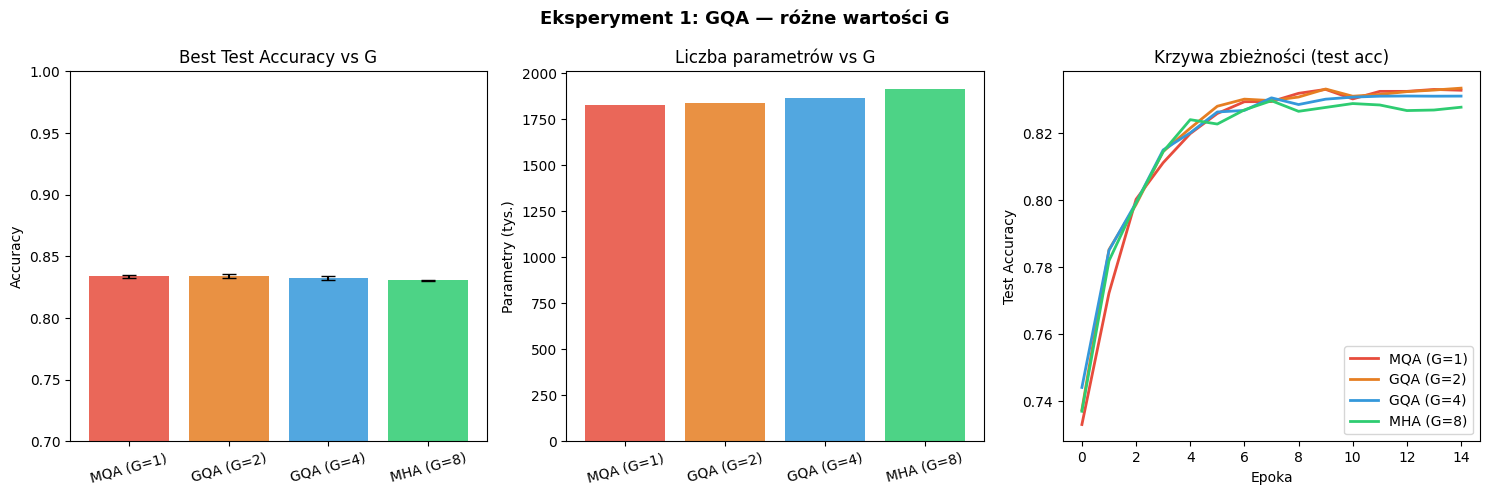


=== Podsumowanie Eksperyment 1 ===
Wariant         Acc mean   Acc std    Params       Inf. time    Overfit gap 
---------------------------------------------------------------------------
MQA (G=1)       0.8337     0.0014      1,828,418      32.05ms   0.0666
GQA (G=2)       0.8341     0.0014      1,840,706      31.27ms   0.0705
GQA (G=4)       0.8323     0.0016      1,865,282      30.59ms   0.0813
MHA (G=8)       0.8306     0.0006      1,914,434      32.40ms   0.0900


In [19]:
# Wizualizacja wyników Eksperymentu 1
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels_exp1 = {1: 'MQA (G=1)', 2: 'GQA (G=2)', 4: 'GQA (G=4)', 8: 'MHA (G=8)'}
colors = {1: '#e74c3c', 2: '#e67e22', 4: '#3498db', 8: '#2ecc71'}

# Accuracy vs G
ax = axes[0]
for G in G_VALUES:
    accs = [r['best_test_acc'] for r in results_exp1[G]]
    mean, std = np.mean(accs), np.std(accs)
    ax.bar(labels_exp1[G], mean, yerr=std, color=colors[G], capsize=5, alpha=0.85)
ax.set_title('Best Test Accuracy vs G')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.7, 1.0)
ax.tick_params(axis='x', rotation=15)

# Parametry vs G
ax = axes[1]
for G in G_VALUES:
    params = results_exp1[G][0]['num_params']
    ax.bar(labels_exp1[G], params / 1000, color=colors[G], alpha=0.85)
ax.set_title('Liczba parametrów vs G')
ax.set_ylabel('Parametry (tys.)')
ax.tick_params(axis='x', rotation=15)

# Krzywa zbieżności
ax = axes[2]
for G in G_VALUES:
    mean_history = np.mean(
        [r['history']['test_acc'] for r in results_exp1[G]], axis=0
    )
    ax.plot(mean_history, label=labels_exp1[G], color=colors[G], linewidth=2)
ax.set_title('Krzywa zbieżności (test acc)')
ax.set_xlabel('Epoka')
ax.set_ylabel('Test Accuracy')
ax.legend()

plt.suptitle('Eksperyment 1: GQA — różne wartości G', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp1_results.png', dpi=150, bbox_inches='tight')
mlflow.log_artifact('exp1_results.png')
plt.show()

# Tabela podsumowująca
print('\n=== Podsumowanie Eksperyment 1 ===')
print(f'{"Wariant":15} {"Acc mean":10} {"Acc std":10} {"Params":12} {"Inf. time":12} {"Overfit gap":12}')
print('-' * 75)
for G in G_VALUES:
    accs = [r['best_test_acc'] for r in results_exp1[G]]
    params = results_exp1[G][0]['num_params']
    inf_t = np.mean([r['inference_time_ms'] for r in results_exp1[G]])
    gap   = np.mean([r['overfitting_gap'] for r in results_exp1[G]])
    print(f'{labels_exp1[G]:15} {np.mean(accs):.4f}     {np.std(accs):.4f}     {params:10,}   {inf_t:8.2f}ms   {gap:.4f}')

## Eksperyment 0 — MHA z różną liczbą głowic H

In [22]:
# Eksperyment 0 — MHA z różną liczbą głowic H
mlflow.end_run()

H_VALUES = [1, 2, 4, 8]
results_exp0 = {}

for H in H_VALUES:
    label = f'MHA_H{H}'
    print(f'\n=== {label} ===')
    accs = []
    for seed in SEEDS:
        # num_groups=H bo MHA to GQA z G=H
        layer_configs = [{'num_groups': H}] * 3
        # model z num_heads=H
        set_seed(seed)
        train_loader, test_loader = get_loaders(max_length=256, batch_size=64)
        model = SentimentClassifier(
            vocab_size=len(vocab),
            d_model=128,
            num_heads=H,        # ← zmieniamy H
            num_layers=3,
            max_length=256,
            dim_feedforward=512,
            dropout=0.1,
            layer_configs=layer_configs
        ).to(DEVICE)

        optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
        criterion = nn.CrossEntropyLoss()
        num_params = model.count_params()
        history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

        with mlflow.start_run(run_name=f'exp0_{label}_seed{seed}'):
            mlflow.log_params({
                'experiment': 'exp0_MHA_heads',
                'H': H, 'seed': seed,
                'num_params': num_params,
                'd_model': 128, 'max_length': 256
            })

            epoch_pbar = tqdm(range(1, 16), desc=f'{label} seed{seed}')
            for epoch in epoch_pbar:
                t_loss, t_acc = train_epoch(model, train_loader, optimizer, criterion, epoch, label)
                v_loss, v_acc = evaluate(model, test_loader, criterion)
                scheduler.step()
                history['train_loss'].append(t_loss)
                history['train_acc'].append(t_acc)
                history['test_loss'].append(v_loss)
                history['test_acc'].append(v_acc)
                mlflow.log_metrics({
                    'train_loss': t_loss, 'train_acc': t_acc,
                    'test_loss': v_loss,  'test_acc': v_acc,
                }, step=epoch)
                epoch_pbar.set_postfix(train_acc=f'{t_acc:.4f}', test_acc=f'{v_acc:.4f}')

            best_acc = max(history['test_acc'])
            gap = history['train_acc'][-1] - history['test_acc'][-1]
            mlflow.log_metrics({'best_test_acc': best_acc, 'overfitting_gap': gap, 'num_params': num_params})
            torch.save(model.state_dict(), f'exp0_{label}_seed{seed}.pt')
            mlflow.log_artifact(f'exp0_{label}_seed{seed}.pt')

        accs.append({'best_test_acc': best_acc, 'overfitting_gap': gap,
                     'num_params': num_params, 'history': history})
    results_exp0[H] = accs

# Podsumowanie
print(f'\n{"Wariant":12} {"Acc mean":10} {"Acc std":10} {"Params":12} {"Overfit gap":12}')
print('-' * 60)
for H in H_VALUES:
    accs  = [r['best_test_acc'] for r in results_exp0[H]]
    gap   = [r['overfitting_gap'] for r in results_exp0[H]]
    params = results_exp0[H][0]['num_params']
    print(f'MHA H={H:<6} {np.mean(accs):.4f}     {np.std(accs):.4f}     {params:10,}   {np.mean(gap):.4f}')


=== MHA_H1 ===


MHA_H1 seed777: 100%|██████████| 15/15 [08:02<00:00, 32.19s/it, test_acc=0.8319, train_acc=0.9075]



=== MHA_H2 ===


MHA_H2 seed777: 100%|██████████| 15/15 [09:19<00:00, 37.32s/it, test_acc=0.8350, train_acc=0.9067]



=== MHA_H4 ===


MHA_H4 seed777: 100%|██████████| 15/15 [11:05<00:00, 44.40s/it, test_acc=0.8349, train_acc=0.9121]



=== MHA_H8 ===


MHA_H8 seed777: 100%|██████████| 15/15 [22:35<00:00, 90.36s/it, test_acc=0.8292, train_acc=0.9180]



Wariant      Acc mean   Acc std    Params       Overfit gap 
------------------------------------------------------------
MHA H=1      0.8345     0.0021      1,914,434   0.0742
MHA H=2      0.8362     0.0015      1,914,434   0.0724
MHA H=4      0.8326     0.0023      1,914,434   0.0813
MHA H=8      0.8306     0.0006      1,914,434   0.0900


## 7. Eksperyment 2 — Strategia grupowania

Przy G=2 porównujemy różne sposoby przypisania głowic Q do grup K,V.

In [21]:
# H=8 głowic, G=2 grupy
# Każda strategia to lista 8 wartości (0 lub 1) — do której grupy należy głowica
mlflow.end_run()
strategies = {
    'naive':    [0, 0, 0, 0, 1, 1, 1, 1],   # sąsiednie
    'random_a': [0, 1, 0, 1, 0, 1, 0, 1],   # co druga
    'random_b': [0, 1, 1, 0, 1, 0, 0, 1],   # losowe
    'reverse':  [1, 1, 1, 1, 0, 0, 0, 0],   # odwrócone
    'split_13': [0, 0, 0, 1, 1, 1, 1, 1],   # nierówny podział 3:5
}

results_exp2 = {}

for strategy_name, assignment in strategies.items():
    print(f'\n=== Strategia: {strategy_name} | assignment: {assignment} ===')
    accs = []
    for seed in SEEDS:
        layer_configs = [{'num_groups': 2, 'group_assignment': assignment}] * 3
        result = run_experiment(
            run_name=f'exp2_{strategy_name}_seed{seed}',
            layer_configs=layer_configs,
            max_length=256,
            seed=seed,
            num_epochs=15,
            extra_params={
                'experiment': 'exp2_grouping_strategy',
                'strategy': strategy_name,
                'G': 2,
                'assignment': str(assignment)
            }
        )
        accs.append(result)
    results_exp2[strategy_name] = accs

print('\n=== Eksperyment 2 zakończony ===')


=== Strategia: naive | assignment: [0, 0, 0, 0, 1, 1, 1, 1] ===


Epochs [exp2_naive_seed42]:   0%|          | 0/15 [00:00<?, ?it/s]

Epochs [exp2_naive_seed42]:   0%|          | 0/15 [00:16<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Wizualizacja Eksperyment 2
fig, ax = plt.subplots(figsize=(10, 5))

strategy_accs = {}
for s_name, results in results_exp2.items():
    accs = [r['best_test_acc'] for r in results]
    strategy_accs[s_name] = accs
    mean, std = np.mean(accs), np.std(accs)
    ax.bar(s_name, mean, yerr=std, capsize=5, alpha=0.85)

ax.set_title('Eksperyment 2: Strategia grupowania (G=2)')
ax.set_ylabel('Best Test Accuracy')
ax.set_ylim(0.7, 1.0)
ax.axhline(y=np.mean([r['best_test_acc'] for r in results_exp1[8]]),
           color='green', linestyle='--', label='MHA baseline', linewidth=2)
ax.legend()
plt.tight_layout()
plt.savefig('exp2_results.png', dpi=150, bbox_inches='tight')
mlflow.log_artifact('exp2_results.png')
plt.show()

print('\n=== Podsumowanie Eksperyment 2 ===')
print(f'{"Strategia":15} {"Acc mean":10} {"Acc std":10}')
print('-' * 40)
for s_name, accs in strategy_accs.items():
    print(f'{s_name:15} {np.mean(accs):.4f}     {np.std(accs):.4f}')

## 8. Eksperyment 3 — Długość sekwencji

Hipoteza: dłuższe sekwencje wymagają większej różnorodności K,V — GQA boli bardziej.

In [23]:
mlflow.end_run()
MAX_LENGTHS = [64, 128, 256, 512]
G_VALUES_EXP3 = [1, 2, 4, 8]

results_exp3 = defaultdict(dict)

for max_len in MAX_LENGTHS:
    for G in G_VALUES_EXP3:
        label = 'MHA' if G == 8 else ('MQA' if G == 1 else f'GQA_G{G}')
        print(f'\n=== max_len={max_len}, {label} ===')

        layer_configs = [{'num_groups': G}] * 3
        result = run_experiment(
            run_name=f'exp3_len{max_len}_{label}',
            layer_configs=layer_configs,
            max_length=max_len,
            seed=42,
            num_epochs=12,
            extra_params={
                'experiment': 'exp3_seq_length',
                'G': G,
                'max_length': max_len
            }
        )
        results_exp3[max_len][G] = result

print('\n=== Eksperyment 3 zakończony ===')


=== max_len=64, MQA ===


Epochs [exp3_len64_MQA]: 100%|██████████| 12/12 [08:39<00:00, 43.26s/it, test_acc=0.7415, train_acc=0.8118]



→ [exp3_len64_MQA] Best acc: 0.7433 | Params: 1,803,842 | Inference: 16.19ms | Memory: 222.7MB


=== max_len=64, GQA_G2 ===


Epochs [exp3_len64_GQA_G2]: 100%|██████████| 12/12 [08:53<00:00, 44.44s/it, test_acc=0.7419, train_acc=0.8203]



→ [exp3_len64_GQA_G2] Best acc: 0.7430 | Params: 1,816,130 | Inference: 15.59ms | Memory: 222.9MB


=== max_len=64, GQA_G4 ===


...


→ [exp3_len512_GQA_G2] Best acc: 0.8447 | Params: 1,873,474 | Inference: 108.93ms | Memory: 526.5MB


=== max_len=512, GQA_G4 ===


Epochs [exp3_len512_GQA_G4]: 100%|██████████| 12/12 [40:39<00:00, 203.33s/it, test_acc=0.8436, train_acc=0.9031]



→ [exp3_len512_GQA_G4] Best acc: 0.8441 | Params: 1,898,050 | Inference: 111.73ms | Memory: 535.2MB


=== max_len=512, MHA ===


Epochs [exp3_len512_MHA]: 100%|██████████| 12/12 [42:13<00:00, 211.15s/it, test_acc=0.8397, train_acc=0.9093]



→ [exp3_len512_MHA] Best acc: 0.8410 | Params: 1,947,202 | Inference: 121.36ms | Memory: 552.8MB


=== Eksperyment 3 zakończony ===


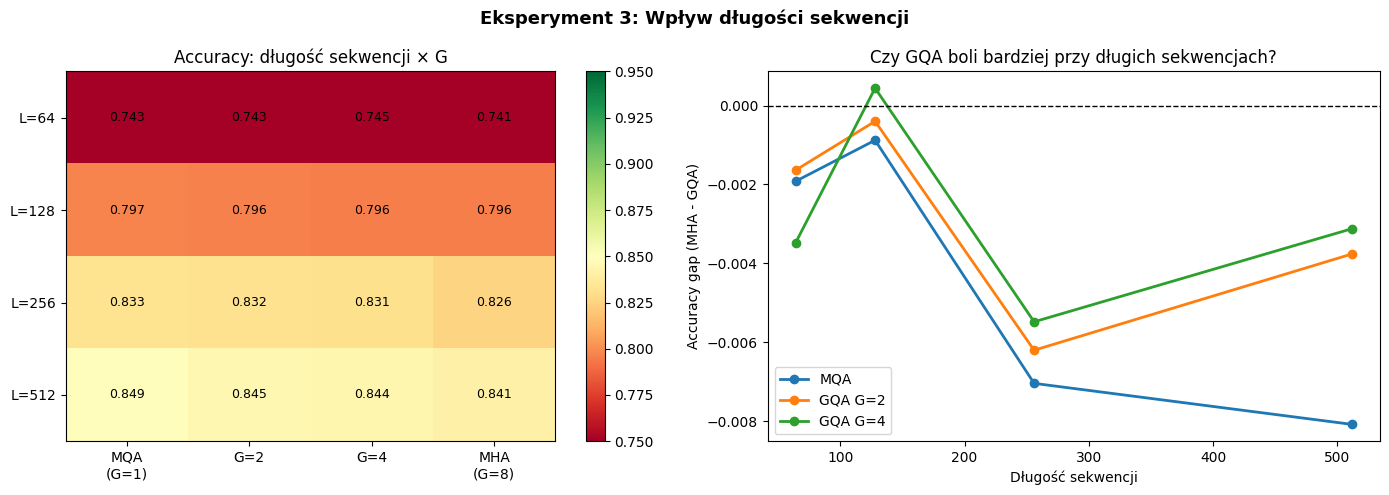

In [ ]:
# Wizualizacja Eksperyment 3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# heatmapa accuracy
ax = axes[0]
matrix = np.array([
    [results_exp3[L][G]['best_test_acc'] for G in G_VALUES_EXP3]
    for L in MAX_LENGTHS
])
im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0.75, vmax=0.95)
ax.set_xticks(range(len(G_VALUES_EXP3)))
ax.set_xticklabels(['MQA\n(G=1)', 'G=2', 'G=4', 'MHA\n(G=8)'])
ax.set_yticks(range(len(MAX_LENGTHS)))
ax.set_yticklabels([f'L={L}' for L in MAX_LENGTHS])
ax.set_title('Accuracy: długość sekwencji × G')
plt.colorbar(im, ax=ax)
for i in range(len(MAX_LENGTHS)):
    for j in range(len(G_VALUES_EXP3)):
        ax.text(j, i, f'{matrix[i,j]:.3f}', ha='center', va='center', fontsize=9)

# gap MHA-GQA vs długość
ax = axes[1]
for G in [1, 2, 4]:
    label = 'MQA' if G == 1 else f'GQA G={G}'
    gaps = [
        results_exp3[L][8]['best_test_acc'] - results_exp3[L][G]['best_test_acc']
        for L in MAX_LENGTHS
    ]
    ax.plot(MAX_LENGTHS, gaps, marker='o', label=label, linewidth=2)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Długość sekwencji')
ax.set_ylabel('Accuracy gap (MHA - GQA)')
ax.set_title('Czy GQA boli bardziej przy długich sekwencjach?')
ax.legend()

plt.suptitle('Eksperyment 3: Wpływ długości sekwencji', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp3_results.png', dpi=150, bbox_inches='tight')
mlflow.log_artifact('exp3_results.png')
plt.show()

## 9. Eksperyment 4 — Layer-wise GQA

GQA tylko w wybranych warstwach — czy ostatnia warstwa jest bardziej wrażliwa?

In [26]:
mlflow.end_run()

# Każda konfiguracja to lista 3 wartości G dla warstw 1, 2, 3
# 8 = MHA, 2 = GQA G=2

layer_wise_configs = {
    'All_MHA':    [8, 8, 8],
    'First_GQA':  [2, 8, 8],
    'Mid_GQA':    [8, 2, 8],
    'Last_GQA':   [8, 8, 2],
    'All_GQA':    [2, 2, 2],
    'First2_GQA': [2, 2, 8],
    'Last2_GQA':  [8, 2, 2],
}

results_exp4 = {}

for config_name, G_per_layer in layer_wise_configs.items():
    print(f'\n=== {config_name}: warstwy G={G_per_layer} ===')
    accs = []
    for seed in SEEDS:
        layer_configs = [{'num_groups': G} for G in G_per_layer]
        result = run_experiment(
            run_name=f'exp4_{config_name}_seed{seed}',
            layer_configs=layer_configs,
            max_length=256,
            seed=seed,
            num_epochs=15,
            extra_params={
                'experiment': 'exp4_layer_wise',
                'config_name': config_name,
                'G_layer1': G_per_layer[0],
                'G_layer2': G_per_layer[1],
                'G_layer3': G_per_layer[2],
            }
        )
        accs.append(result)
    results_exp4[config_name] = accs

print('\n=== Eksperyment 4 zakończony ===')


=== All_MHA: warstwy G=[8, 8, 8] ===


Epochs [exp4_All_MHA_seed42]: 100%|██████████| 15/15 [28:08<00:00, 112.57s/it, test_acc=0.8272, train_acc=0.9167]



→ [exp4_All_MHA_seed42] Best acc: 0.8300 | Params: 1,914,434 | Inference: 48.96ms | Memory: 315.8MB



Epochs [exp4_All_MHA_seed123]: 100%|██████████| 15/15 [27:52<00:00, 111.52s/it, test_acc=0.8271, train_acc=0.9188]



→ [exp4_All_MHA_seed123] Best acc: 0.8304 | Params: 1,914,434 | Inference: 52.73ms | Memory: 315.8MB



...


→ [exp4_Last2_GQA_seed42] Best acc: 0.8334 | Params: 1,865,282 | Inference: 48.77ms | Memory: 306.6MB



Epochs [exp4_Last2_GQA_seed123]: 100%|██████████| 15/15 [26:34<00:00, 106.28s/it, test_acc=0.8312, train_acc=0.9169]



→ [exp4_Last2_GQA_seed123] Best acc: 0.8332 | Params: 1,865,282 | Inference: 45.01ms | Memory: 306.6MB



Epochs [exp4_Last2_GQA_seed777]: 100%|██████████| 15/15 [26:17<00:00, 105.17s/it, test_acc=0.8308, train_acc=0.9118]



→ [exp4_Last2_GQA_seed777] Best acc: 0.8331 | Params: 1,865,282 | Inference: 50.10ms | Memory: 306.6MB


=== Eksperyment 4 zakończony ===


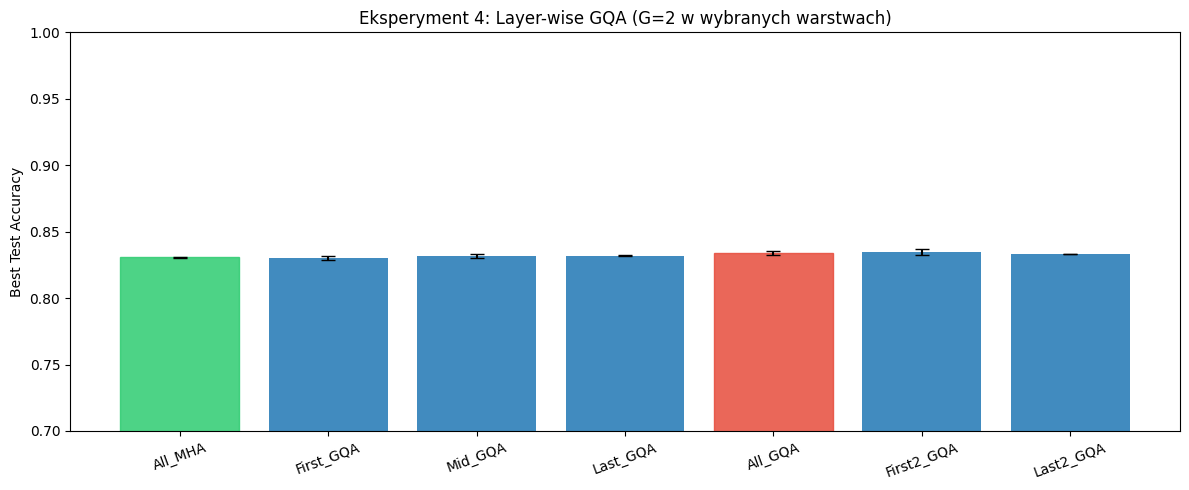


=== Podsumowanie Eksperyment 4 ===
Konfiguracja    Acc mean   Acc std    Params      
-------------------------------------------------------
All_MHA         0.8306     0.0006      1,914,434
First_GQA       0.8299     0.0015      1,889,858
Mid_GQA         0.8316     0.0014      1,889,858
Last_GQA        0.8320     0.0003      1,889,858
All_GQA         0.8341     0.0014      1,840,706
First2_GQA      0.8345     0.0022      1,865,282
Last2_GQA       0.8332     0.0001      1,865,282


In [27]:
# Wizualizacja Eksperyment 4
fig, ax = plt.subplots(figsize=(12, 5))

config_names = list(layer_wise_configs.keys())
means = [np.mean([r['best_test_acc'] for r in results_exp4[c]]) for c in config_names]
stds  = [np.std( [r['best_test_acc'] for r in results_exp4[c]]) for c in config_names]

bars = ax.bar(config_names, means, yerr=stds, capsize=5, alpha=0.85)
bars[0].set_color('#2ecc71')  # All_MHA zielony
bars[-3].set_color('#e74c3c') # All_GQA czerwony

ax.set_title('Eksperyment 4: Layer-wise GQA (G=2 w wybranych warstwach)')
ax.set_ylabel('Best Test Accuracy')
ax.set_ylim(0.7, 1.0)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('exp4_results.png', dpi=150, bbox_inches='tight')
mlflow.log_artifact('exp4_results.png')
plt.show()

print('\n=== Podsumowanie Eksperyment 4 ===')
print(f'{"Konfiguracja":15} {"Acc mean":10} {"Acc std":10} {"Params":12}')
print('-' * 55)
for c in config_names:
    accs   = [r['best_test_acc'] for r in results_exp4[c]]
    params = results_exp4[c][0]['num_params']
    print(f'{c:15} {np.mean(accs):.4f}     {np.std(accs):.4f}     {params:10,}')

## 10. Podsumowanie wszystkich eksperymentów

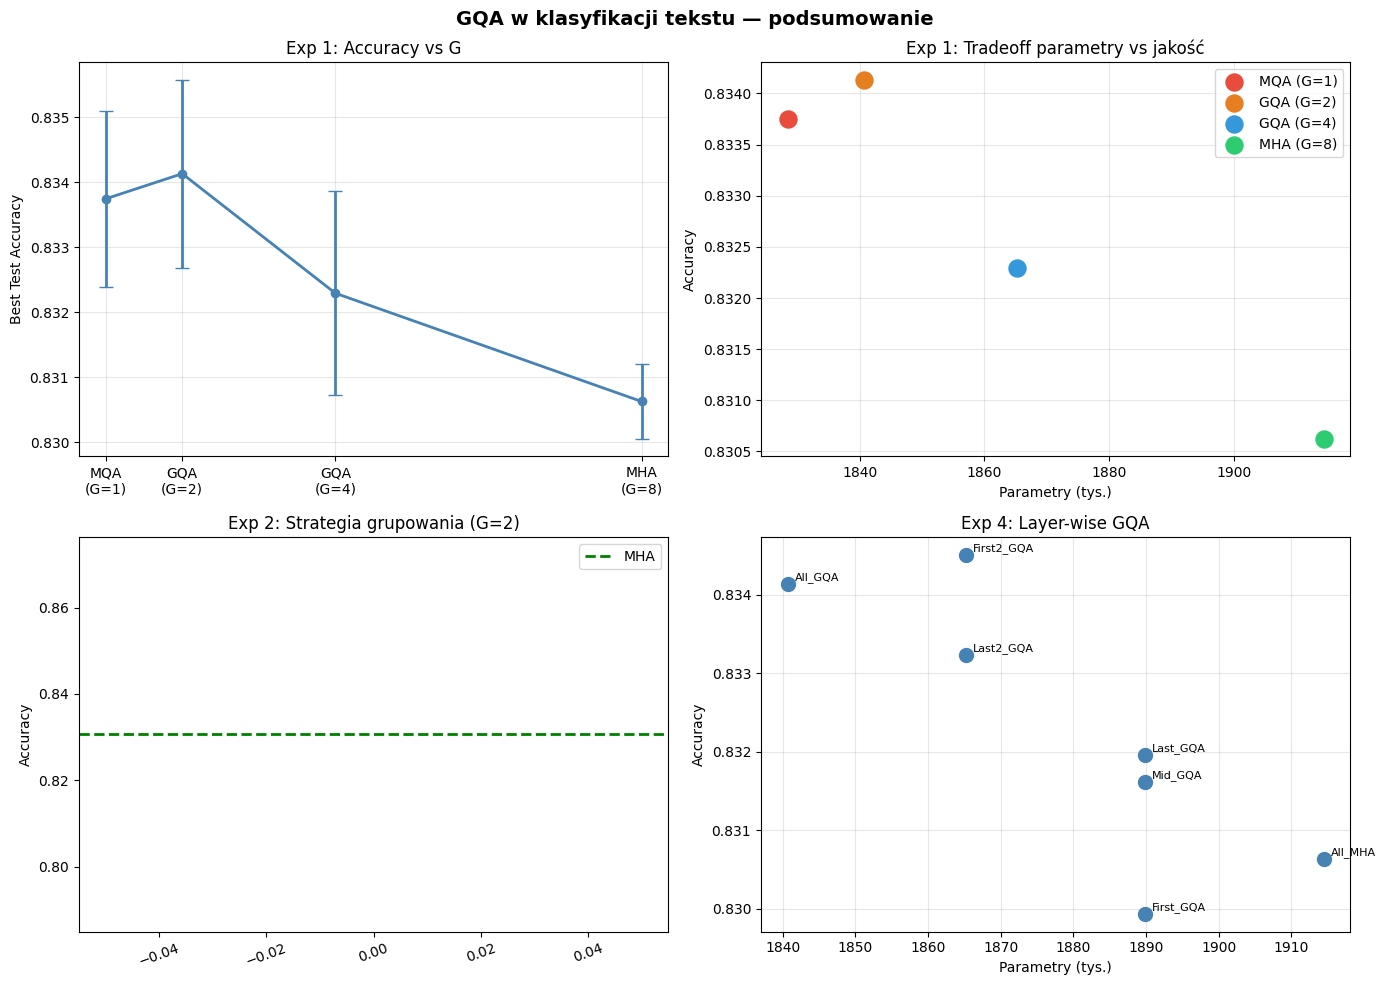

Wszystkie eksperymenty zakończone i zalogowane do MLflow.


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Exp 1 — accuracy vs G
ax = axes[0, 0]
G_labels = ['MQA\n(G=1)', 'GQA\n(G=2)', 'GQA\n(G=4)', 'MHA\n(G=8)']
means = [np.mean([r['best_test_acc'] for r in results_exp1[G]]) for G in G_VALUES]
stds  = [np.std( [r['best_test_acc'] for r in results_exp1[G]]) for G in G_VALUES]
params_list = [results_exp1[G][0]['num_params'] for G in G_VALUES]

ax.errorbar(G_VALUES, means, yerr=stds, marker='o', linewidth=2, capsize=5, color='steelblue')
ax.set_xticks(G_VALUES)
ax.set_xticklabels(G_labels)
ax.set_title('Exp 1: Accuracy vs G')
ax.set_ylabel('Best Test Accuracy')
ax.grid(True, alpha=0.3)

# Exp 1 — parametry vs accuracy scatter
ax = axes[0, 1]
for G, label, color in zip(G_VALUES, G_labels, ['#e74c3c','#e67e22','#3498db','#2ecc71']):
    acc = np.mean([r['best_test_acc'] for r in results_exp1[G]])
    p   = results_exp1[G][0]['num_params'] / 1000
    ax.scatter(p, acc, s=150, color=color, label=label.replace('\n', ' '), zorder=5)
ax.set_xlabel('Parametry (tys.)')
ax.set_ylabel('Accuracy')
ax.set_title('Exp 1: Tradeoff parametry vs jakość')
ax.legend()
ax.grid(True, alpha=0.3)

# Exp 2 — strategia grupowania
ax = axes[1, 0]
s_names = list(results_exp2.keys())
s_means = [np.mean([r['best_test_acc'] for r in results_exp2[s]]) for s in s_names]
s_stds  = [np.std( [r['best_test_acc'] for r in results_exp2[s]]) for s in s_names]
ax.bar(s_names, s_means, yerr=s_stds, capsize=5, alpha=0.85, color='steelblue')
ax.axhline(means[-1], color='green', linestyle='--', label='MHA', linewidth=2)
ax.set_title('Exp 2: Strategia grupowania (G=2)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.tick_params(axis='x', rotation=20)

# Exp 4 — layer-wise
ax = axes[1, 1]
lw_names  = list(layer_wise_configs.keys())
lw_means  = [np.mean([r['best_test_acc'] for r in results_exp4[c]]) for c in lw_names]
lw_stds   = [np.std( [r['best_test_acc'] for r in results_exp4[c]]) for c in lw_names]
lw_params = [results_exp4[c][0]['num_params'] / 1000 for c in lw_names]
ax.scatter(lw_params, lw_means, s=100, color='steelblue', zorder=5)
for name, x, y in zip(lw_names, lw_params, lw_means):
    ax.annotate(name, (x, y), textcoords='offset points', xytext=(5, 3), fontsize=8)
ax.set_xlabel('Parametry (tys.)')
ax.set_ylabel('Accuracy')
ax.set_title('Exp 4: Layer-wise GQA')
ax.grid(True, alpha=0.3)

plt.suptitle('GQA w klasyfikacji tekstu — podsumowanie', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('summary.png', dpi=150, bbox_inches='tight')
mlflow.log_artifact('summary.png')
plt.show()

print('Wszystkie eksperymenty zakończone i zalogowane do MLflow.')